In [1]:
import os
import numpy as np
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import Python_Scripts.garch as garch
import Python_Scripts.tsa as tsa
from scipy import stats, signal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

In [3]:
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile=universeFilePath, sheetName='Sheet1',
                                                             startDate=closeDf.first_valid_index())
allTradingDatesDf.reset_index(drop=True, inplace=True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace=True)

In [4]:
mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [5]:
rebalDates = ['2024-10-18']
resultDf = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
resultDf14 = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
stDf = pd.DataFrame(index=rebalDates, columns=['12', '14'])

In [6]:
i = 0

rebalDate = rebalDates[i]

wSize = [45, 60, 90, 100]

sim = mk.Match(closeMergedDf, rebalDate, windowSize=wSize[0], threshold=0.85)
reg = sim.getRegime()

print(reg)
print(rebalDate)

indexLists = [1, 2,3,4]

    idx      start        end        dp
0  5555 2018-02-20 2018-04-27  3.207108
1  5556 2018-02-21 2018-04-30  3.590996
2  5554 2018-02-19 2018-04-26  3.599230
3  2310 2005-01-24 2005-03-30  3.825316
4  2309 2005-01-20 2005-03-29  3.846647
2024-10-18


1
2
3
4


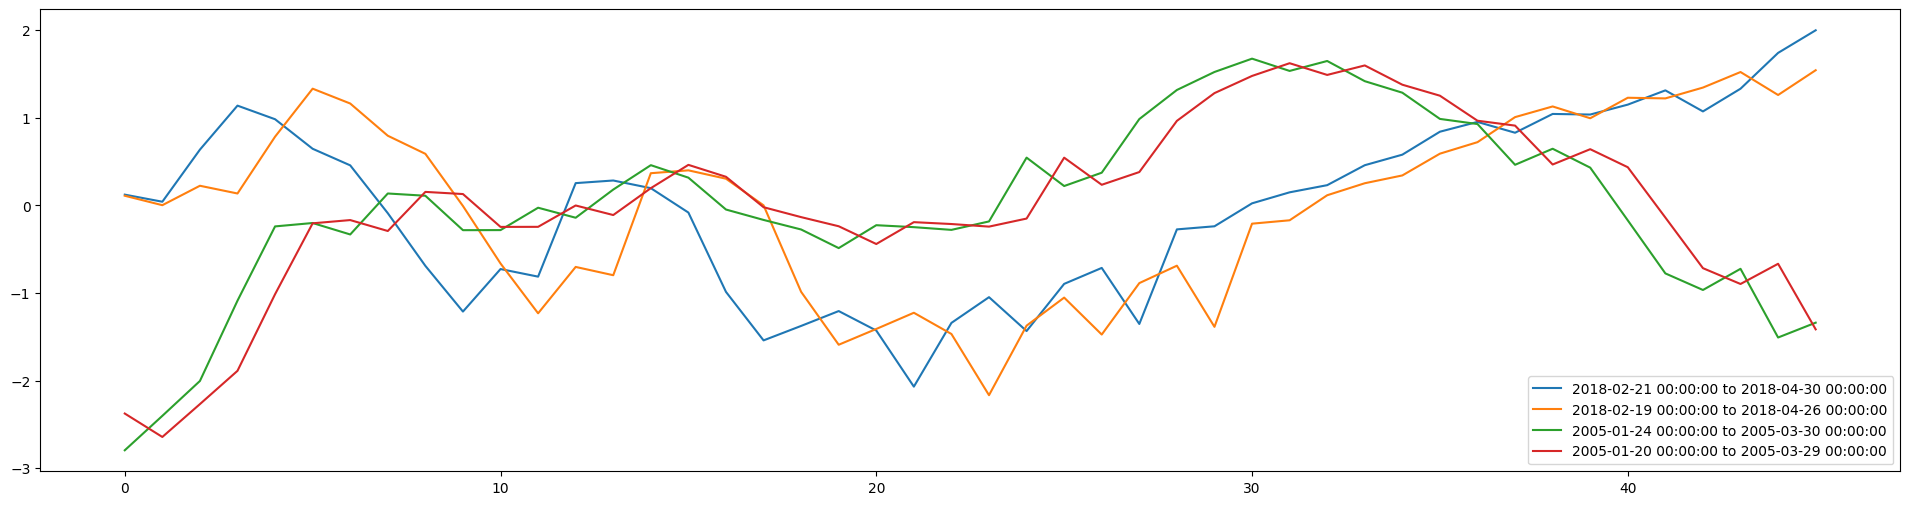

In [7]:
plt.figure(figsize=(24, 6))
ax = plt.gca()
# sim.plotMatch(ax)
for i in indexLists:
    ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[i].start: reg.iloc[i].end].values),
            label='{} to {}'.format(str(reg.iloc[i].start), str(reg.iloc[i].end)))

    print(i)
# ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[0].start: reg.iloc[0].end].values), color='k', lw=4, label='Query')
ax.legend()

In [8]:
qReg = tsa.Preprocess(closeMergedDf, start=reg.start.iloc[indexLists[1]], end=reg.end.iloc[indexLists[1]]).getProcessedData()
qRegRet = tsa.Returns(qReg).getLogReturns()
qRoi = tsa.Preprocess(closeMergedDf, start=reg.end.iloc[indexLists[1]] - datetime.timedelta(21),).getProcessedData()[:90+14]
print(qRoi)

               .NSEI
Date                
2018-04-05  10325.15
2018-04-06  10331.60
2018-04-09  10379.35
2018-04-10  10402.25
2018-04-11  10417.15
...              ...
2018-08-27  11691.95
2018-08-28  11738.50
2018-08-29  11691.90
2018-08-30  11676.80
2018-08-31  11680.50

[104 rows x 1 columns]


0.7


<Axes: >

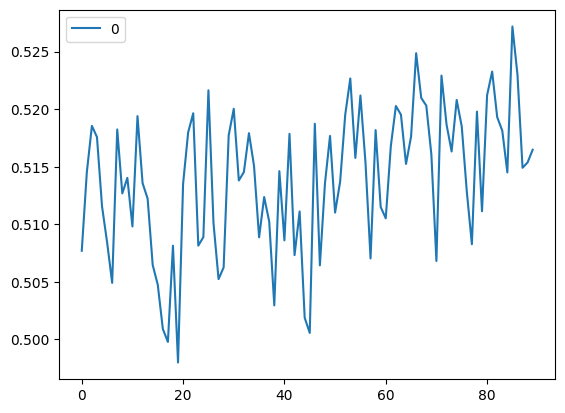

In [9]:
frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
print(frCoff)
qFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
qFR = qFD.getDifferencedSeries(np.log(qRoi))
qFR.plot()

In [10]:
qFR12 = qFR[:45]
qFR14 = qFR[:90]

In [11]:
oRoi = closeMergedDf.loc[:rebalDate][-15:]
oFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
oFR = oFD.getDifferencedSeries(np.log(oRoi))

In [12]:
# ---- 2-month window (45 observations) -----------------
mod12 = garch.Model(qFR12,
              mean='Zero',
              vol='GARCH',
              p=1, q=1,
              dist='Normal')

print(mod12.getParameters())

            params   tvalues   pvalues   std_err
omega     0.130684  1.570815  0.116226  0.083195
alpha[1]  0.199991  1.181609  0.237361  0.169253
beta[1]   0.299990  0.747472  0.454779  0.401340


In [13]:
# GARCH simulation object
rep = 35
garch_sim12 = garch.SimulateVariance(mod12,
                               Data=None,
                               init_Val=oFR.iloc[0].values.flatten(),
                               nSim=45,
                               nRep=rep)

sims12 = garch_sim12.getValues()   # DataFrame (45 rows, 35 columns)


In [14]:
oRoi

,.NSEI
Date,
2024-09-27,26178.95
2024-09-30,25810.85
2024-10-01,25796.90
2024-10-03,25250.10
2024-10-04,25014.60
2024-10-07,24795.75
2024-10-08,25013.15
2024-10-09,24981.95
2024-10-10,24998.45


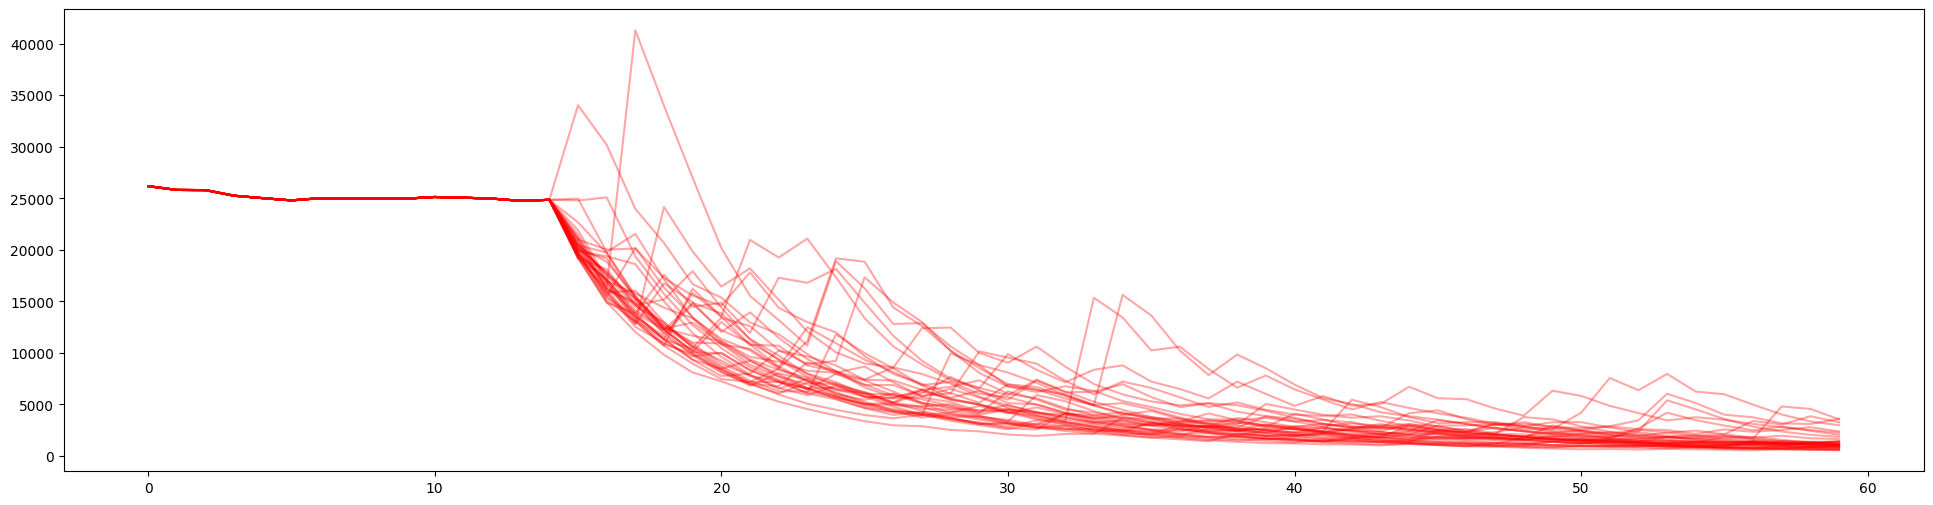

In [15]:
# back from fractionally-differenced space to price space
simPrice = []
for i in range(rep):
    simPrice.append(
        tsa.BackOperation(oRoi.values.flatten(),
                          sims12.iloc[:, i],
                          fraction=frCoff).getPrediction().values.flatten()
    )

# plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()
#plt.savefig(f'../Investment Research_N/smallcases/Model smallcase/Cash/LM/{rebalDate}_Pred12_SC100Df.png')

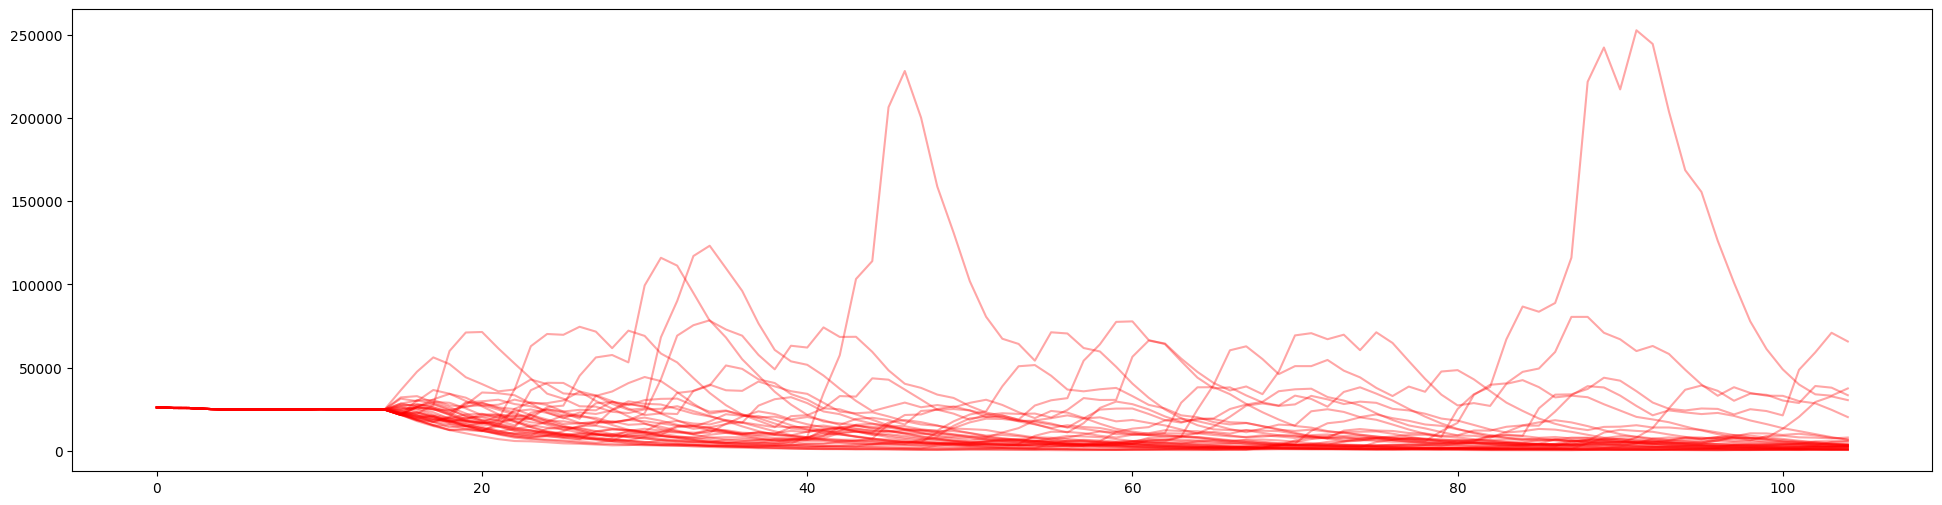

In [16]:
# ---- 3-month window (90 observations) -----------------
mod14 = garch.Model(qFR14, mean='Zero', vol='GARCH', p=1, q=1, dist='Normal')

garch_sim14 = garch.SimulateVariance(mod14,
                               init_Val=oFR.iloc[0].values.flatten(),
                               nSim=90,
                               nRep=rep)
sims14 = garch_sim14.getValues()

simPrice14 = []
for i in range(rep):
    simPrice14.append(
        tsa.BackOperation(oRoi.values.flatten(),
                          sims14.iloc[:, i],
                          fraction=frCoff).getPrediction().values.flatten()
    )

# plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()
#plt.savefig(f'../Investment Research_N/smallcases/Model smallcase/Cash/LM/{rebalDate}_Pred14_SC100Df.png')

In [17]:
simulDf12 = pd.DataFrame(simPrice).T
simulDf14 = pd.DataFrame(simPrice14).T
resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x : (x[35] / x[13])-1))
resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x : np.std(x.pct_change(1))))
resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate]['Avg_Std'] = simulDf12.mean(1).pct_change(1).std()
stDf.loc[rebalDate]['12'] = np.mean(simulDf12.pct_change(1).std())

In [18]:
resultDf

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std
2024-10-18,-0.844214,0.16226,-0.852718,0.048258


In [19]:
simulDf12

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,...,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000
1,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,...,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000
2,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,...,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000
3,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,...,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000
4,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,...,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000
5,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,...,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000
6,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,...,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000
7,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,...,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000
8,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,...,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000
9,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,...,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000


In [20]:
stDf

,12,14
2024-10-18,0.163653,NaN


In [21]:
resultDf

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std
2024-10-18,-0.844214,0.16226,-0.852718,0.048258


    idx      start        end        dp
0  5555 2018-02-20 2018-04-27  3.207108
1  5556 2018-02-21 2018-04-30  3.590996
2  5554 2018-02-19 2018-04-26  3.599230
3  2310 2005-01-24 2005-03-30  3.825316
4  2309 2005-01-20 2005-03-29  3.846647
2024-10-18
            params      tvalues       pvalues       std_err
mu        0.001279  1037.600045  0.000000e+00  1.232173e-06
omega     0.000001  8624.559741  0.000000e+00  1.295451e-10
alpha[1]  0.199992     1.465295  1.428405e-01  1.364861e-01
beta[1]   0.779965     8.166599  3.172046e-16  9.550667e-02
             Ret_Avg  Std_Avg   Avg_Ret   Avg_Std
2024-10-18 -0.033047  0.00063 -0.053266  0.000084
                 12   14
2024-10-18  0.00063  NaN


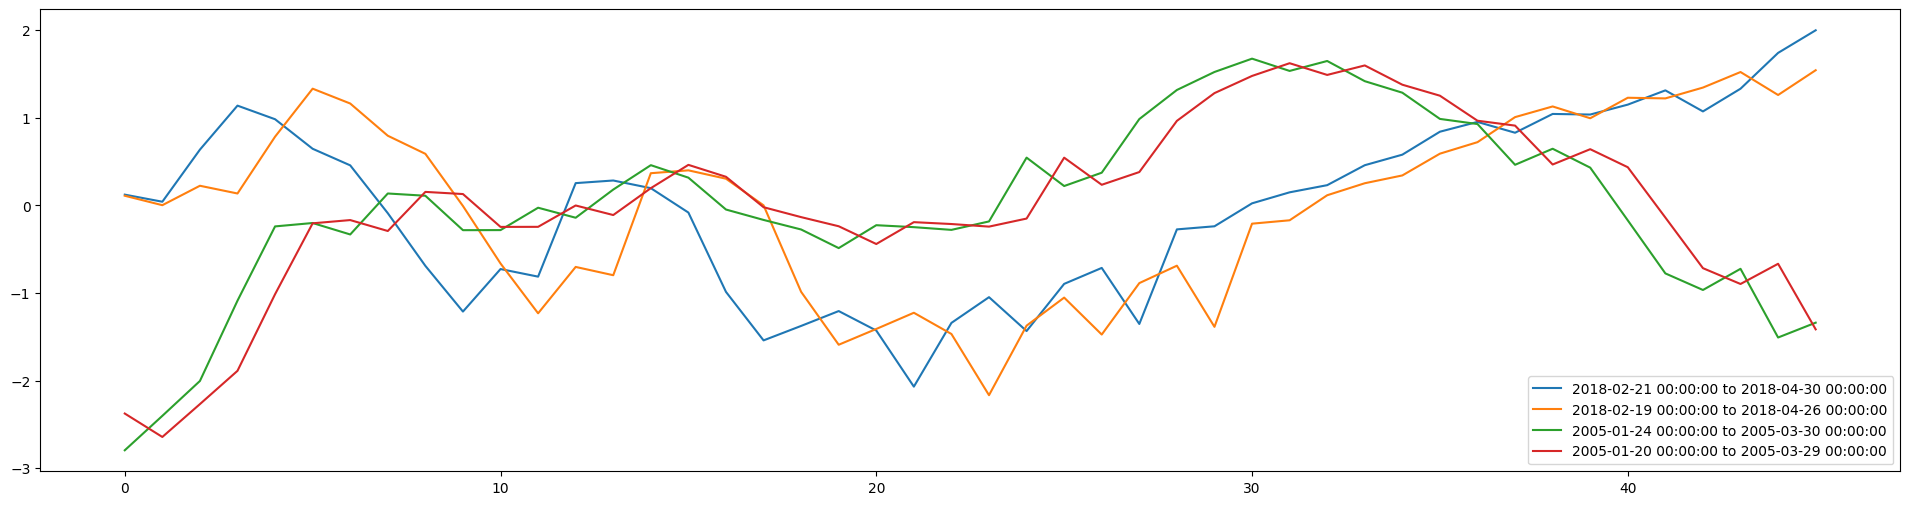

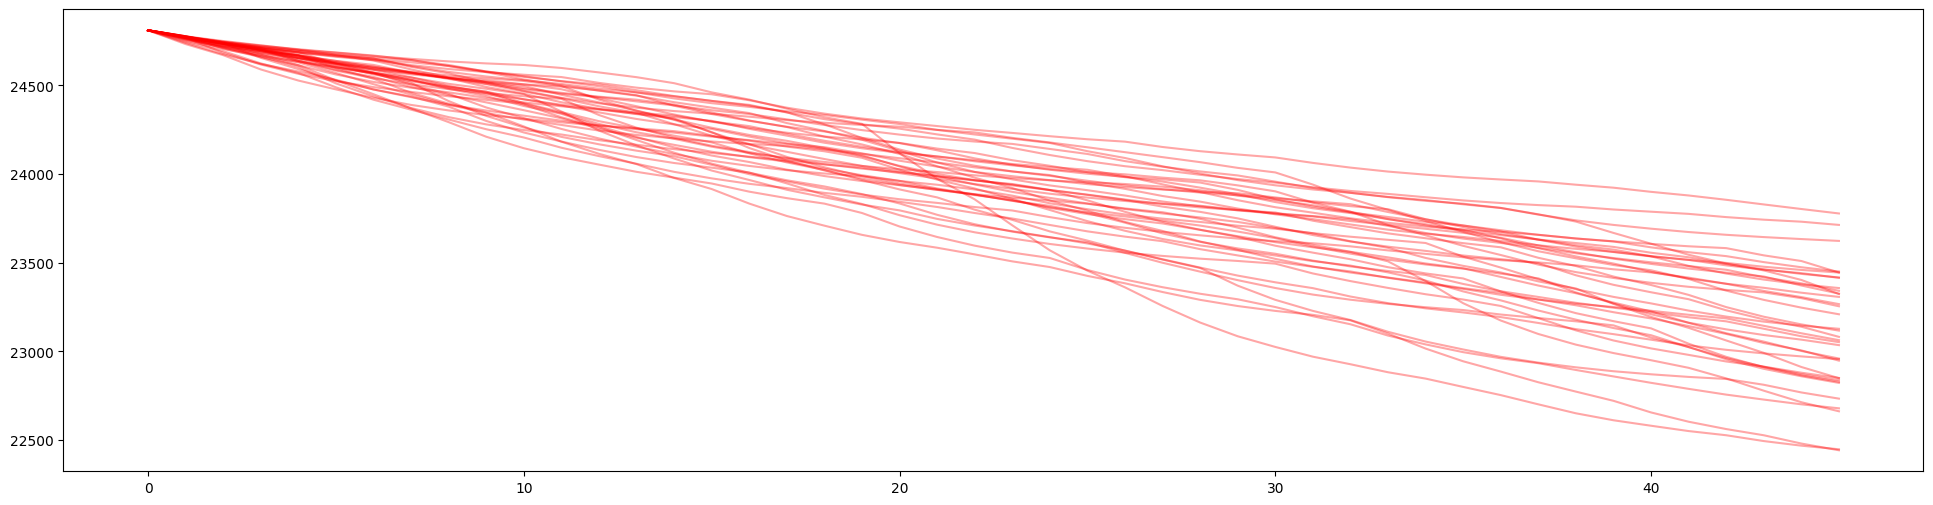

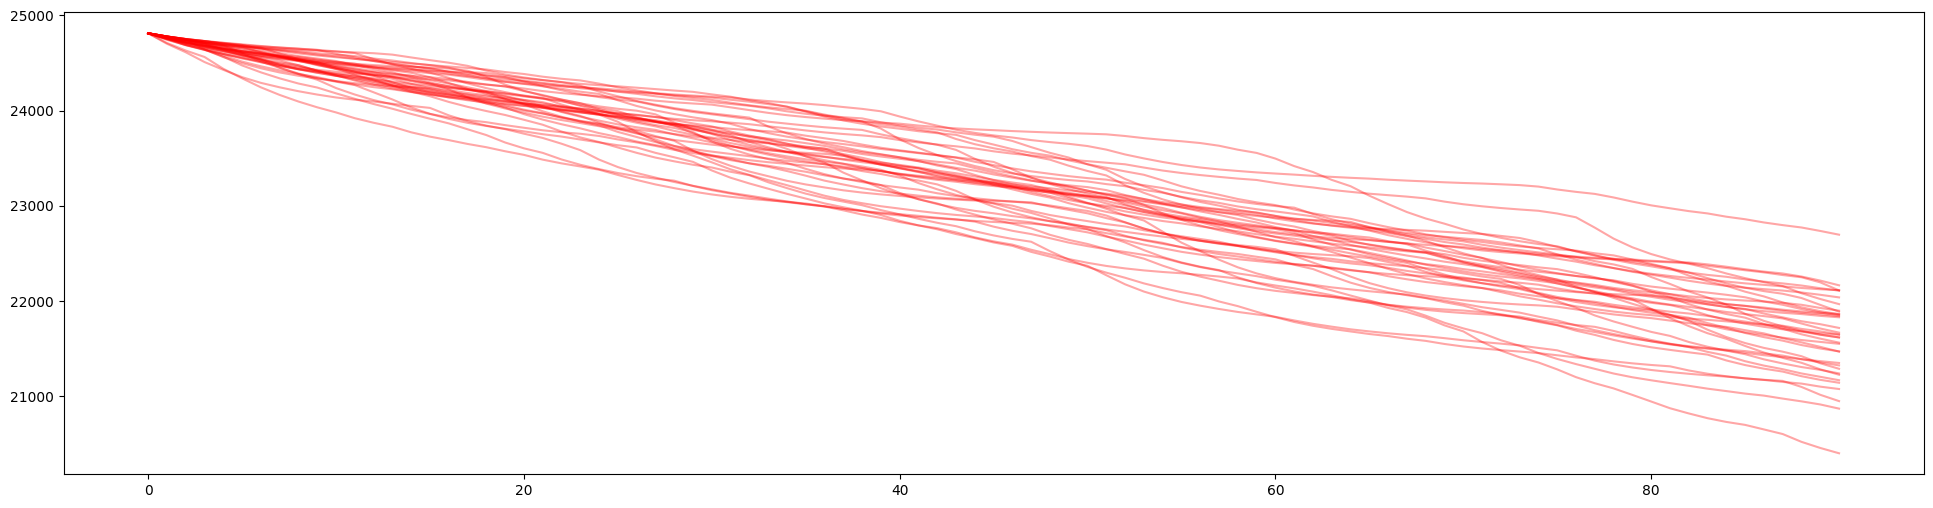

In [22]:
import os
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import Python_Scripts.garch as garch
import Python_Scripts.tsa as tsa
from scipy import stats, signal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import datetime

# Load close prices
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

# Load trading dates
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=universeFilePath,
    sheetName='Sheet1',
    startDate=closeDf.first_valid_index()
)
allTradingDatesDf.reset_index(drop=True, inplace=True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

rebalDates = ['2024-10-18']
resultDf = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
stDf = pd.DataFrame(index=rebalDates, columns=['12', '14'])

i = 0
rebalDate = rebalDates[i]
wSize = [45, 60, 90, 100]

# regime matching
sim = mk.Match(closeMergedDf, rebalDate, windowSize=wSize[0], threshold=0.85)
reg = sim.getRegime()

print(reg)
print(rebalDate)

indexLists = [1, 2, 3, 4]

# Plot matched regimes
plt.figure(figsize=(24, 6))
ax = plt.gca()
for i in indexLists:
    ax.plot(
        stats.zscore(closeMergedDf.loc[reg.iloc[i].start: reg.iloc[i].end].values),
        label='{} to {}'.format(str(reg.iloc[i].start), str(reg.iloc[i].end))
    )
ax.legend()

# Classic GARCH approach: compute log returns
qReg = closeMergedDf.loc[reg.start.iloc[indexLists[1]]: reg.end.iloc[indexLists[1]]]
qRegRet = np.log(qReg).diff().dropna()  # daily log returns
oRoi = closeMergedDf.loc[:rebalDate][-15:]

# ---- 2-month window (45 observations) -----------------
qRet12 = qRegRet.iloc[:45]

mod12 = garch.Model(
    qRet12,
    mean='Constant',
    vol='GARCH',
    p=1, q=1,
    dist='Normal'
)

print(mod12.getParameters())

# GARCH simulation object
rep = 35
garch_sim12 = garch.SimulateVariance(
    mod12,
    Data=None,
    init_Val=qRet12.iloc[0].values.flatten(),
    nSim=45,
    nRep=rep
)

sims12 = garch_sim12.getValues()  # DataFrame (45 rows, 35 columns)

# back to price space
simPrice = []
lastPrice = oRoi.iloc[-1, 0]  # start from last observed price
for i in range(rep):
    cumReturns = sims12.iloc[:, i].cumsum()
    simPrice.append(lastPrice * np.exp(cumReturns.values))

# plot simulations
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

# ---- 3-month window (90 observations) -----------------
qRet14 = qRegRet.iloc[:90]

mod14 = garch.Model(qRet14, mean='Constant', vol='GARCH', p=1, q=1, dist='Normal')

garch_sim14 = garch.SimulateVariance(
    mod14,
    init_Val=qRet14.iloc[0].values.flatten(),
    nSim=90,
    nRep=rep
)
sims14 = garch_sim14.getValues()

simPrice14 = []
for i in range(rep):
    cumReturns = sims14.iloc[:, i].cumsum()
    simPrice14.append(lastPrice * np.exp(cumReturns.values))

# plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

# Calculate metrics
simulDf12 = pd.DataFrame(simPrice).T
simulDf14 = pd.DataFrame(simPrice14).T

resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate]['Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
stDf.loc[rebalDate]['12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))

print(resultDf)
print(stDf)


    idx      start        end        dp
0  5555 2018-02-20 2018-04-27  3.207108
1  5556 2018-02-21 2018-04-30  3.590996
2  5554 2018-02-19 2018-04-26  3.599230
3  2310 2005-01-24 2005-03-30  3.825316
4  2309 2005-01-20 2005-03-29  3.846647
2024-10-18
             Ret_Avg   Std_Avg   Avg_Ret  Avg_Std  Ret_Avg_3M  Std_Avg_3M  \
2024-10-18  0.038751  0.031218  0.054128  0.00429     0.08388    0.040051   

            Avg_Ret_3M  Avg_Std_3M  
2024-10-18    0.119865    0.006807  
                  12        14
2024-10-18  0.031218  0.040051


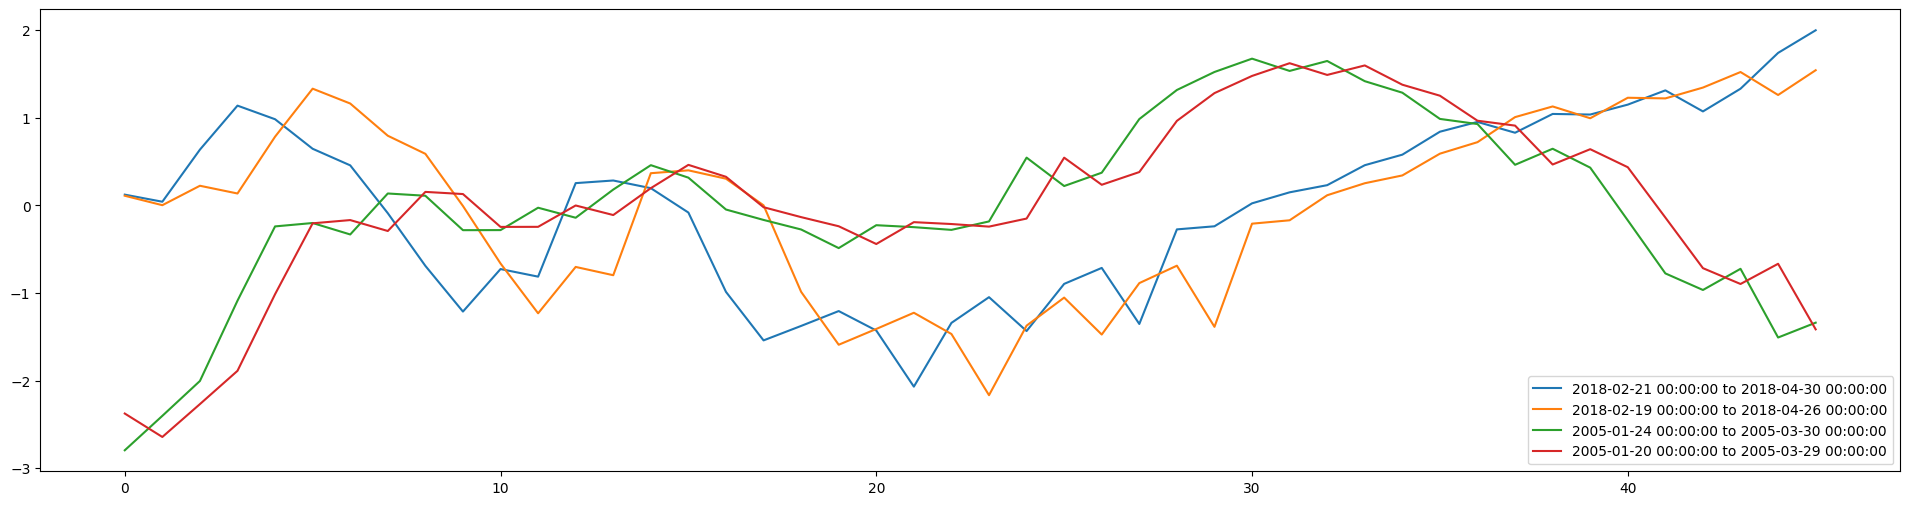

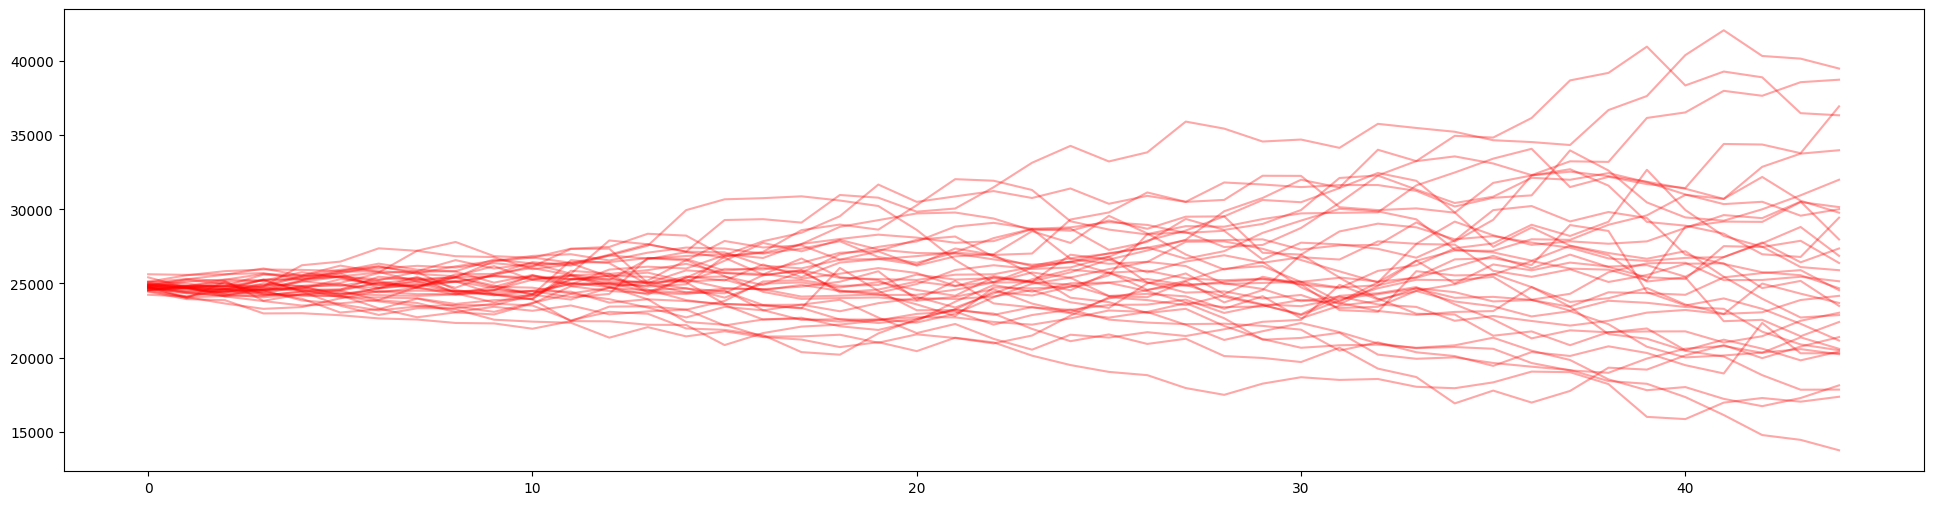

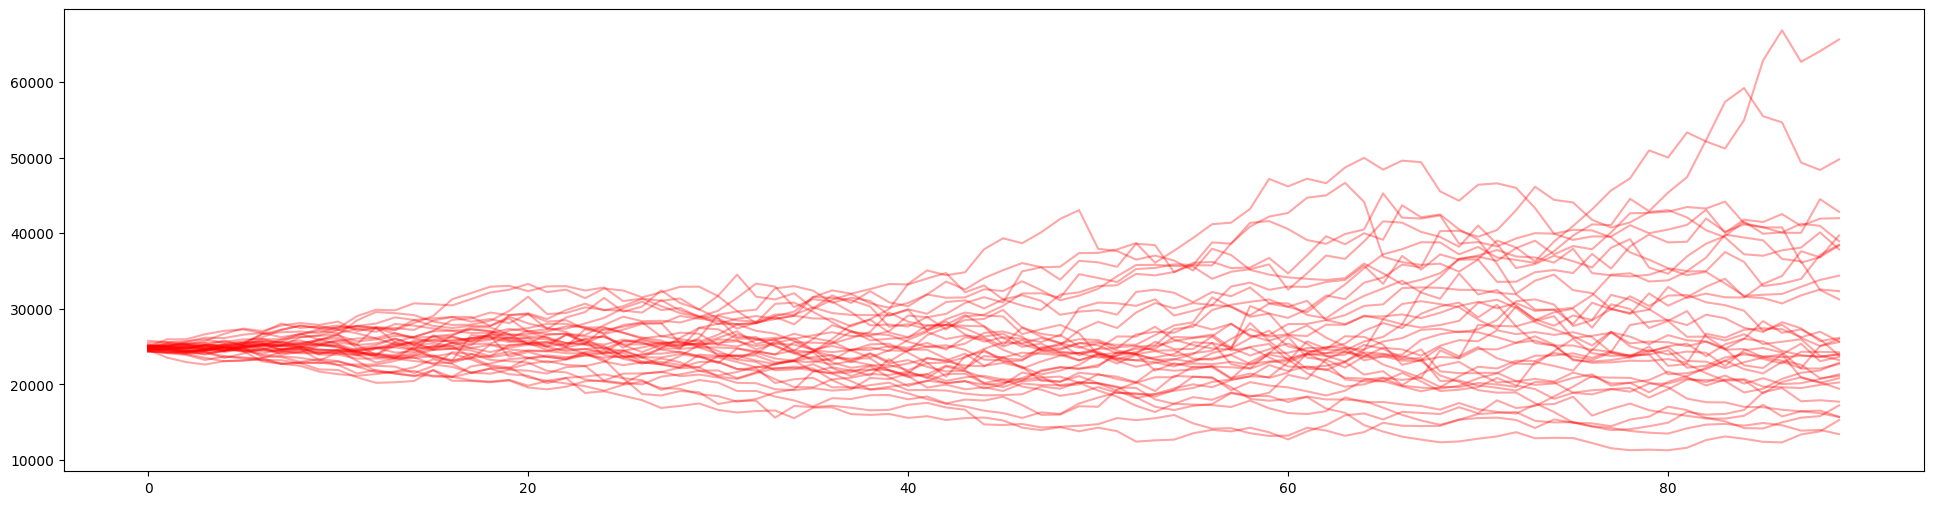

In [62]:
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import matplotlib.pyplot as plt
import datetime
from arch import arch_model
from scipy.stats import t
from scipy import stats

# Load close prices
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

# Load trading dates
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=universeFilePath,
    sheetName='Sheet1',
    startDate=closeDf.first_valid_index()
)
allTradingDatesDf.reset_index(drop=True, inplace=True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

rebalDates = ['2024-10-18']
resultDf = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
stDf = pd.DataFrame(index=rebalDates, columns=['12', '14'])

i = 0
rebalDate = rebalDates[i]
wSize = [45, 60, 90, 100]

# regime matching
sim = mk.Match(closeMergedDf, rebalDate, windowSize=wSize[0], threshold=0.85)
reg = sim.getRegime()
print(reg)
print(rebalDate)

indexLists = [1, 2, 3, 4]

# Plot matched regimes
plt.figure(figsize=(24, 6))
ax = plt.gca()
for i in indexLists:
    ax.plot(
        stats.zscore(closeMergedDf.loc[reg.iloc[i].start: reg.iloc[i].end].values),
        label='{} to {}'.format(str(reg.iloc[i].start), str(reg.iloc[i].end))
    )
ax.legend()

# Compute log returns
qReg = closeMergedDf.loc[reg.start.iloc[indexLists[1]]: reg.end.iloc[indexLists[1]]]
qRegRet = np.log(qReg).diff().dropna()
oRoi = closeMergedDf.loc[:rebalDate][-15:]


def simulate_figarch_prices(returns, last_price, horizon=45, rep=35):
    """
    Fit FIGARCH, forecast conditional volatility, and simulate forward price paths.
    """
    # Fit FIGARCH(1,d,1) with t-distribution
    figarch_mod = arch_model(returns, vol='FIGARCH', p=1, q=1, dist='t')
    figarch_fit = figarch_mod.fit(update_freq=5, disp='off')

    # Forecast conditional volatility
    forecast = figarch_fit.forecast(horizon=horizon, method='analytic')
    sigma_forecast = forecast.variance.values[-1, :] ** 0.5  # last row

    # Degrees of freedom for t-distribution
    df_t = figarch_fit.params['nu']

    # Simulate forward returns
    sim_returns = np.zeros((horizon, rep))
    for i in range(rep):
        sim_returns[:, i] = sigma_forecast * t.rvs(df=df_t, size=horizon)

    # Convert returns to price paths
    sim_prices = [last_price * np.exp(sim_returns[:, i].cumsum()) for i in range(rep)]

    return sim_prices, figarch_fit


# ---- 2-month window (45 observations) -----------------
qRet12 = qRegRet.iloc[:45]
last_price = oRoi.iloc[-1, 0]

simPrice12, figarch_fit12 = simulate_figarch_prices(qRet12, last_price, horizon=45, rep=35)

# plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice12).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

#----
# ---- 3-month window (90 observations) -----------------
qRet14 = qRegRet.iloc[:90]
simPrice14, figarch_fit14 = simulate_figarch_prices(qRet14, last_price, horizon=90, rep=35)

fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

# Calculate metrics
simulDf12 = pd.DataFrame(simPrice12).T
simulDf14 = pd.DataFrame(simPrice14).T

# ----- 2-month (45-day) results -----
# resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
# resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
# resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
# resultDf.loc[rebalDate]['Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
# stDf.loc[rebalDate]['12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))
resultDf.loc[rebalDate, 'Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
resultDf.loc[rebalDate, 'Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
stDf.loc[rebalDate, '12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))

# ----- 3-month (90-day) results -----
resultDf.loc[rebalDate, 'Ret_Avg_3M'] = np.mean(simulDf14.apply(lambda x: (x[70] / x[20]) - 1))
resultDf.loc[rebalDate, 'Std_Avg_3M'] = np.mean(simulDf14.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret_3M'] = (simulDf14.mean(1)[70] / simulDf14.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std_3M'] = np.std(np.diff(np.log(simulDf14.mean(1))))
stDf.loc[rebalDate, '14'] = np.mean(np.std(np.diff(np.log(simulDf14), axis=0), axis=0))

print(resultDf)
print(stDf)


12-day actual: 0.012750013752411693 0.00686609129721503
14-day actual: 0.06830905851531388 0.007101314753071043


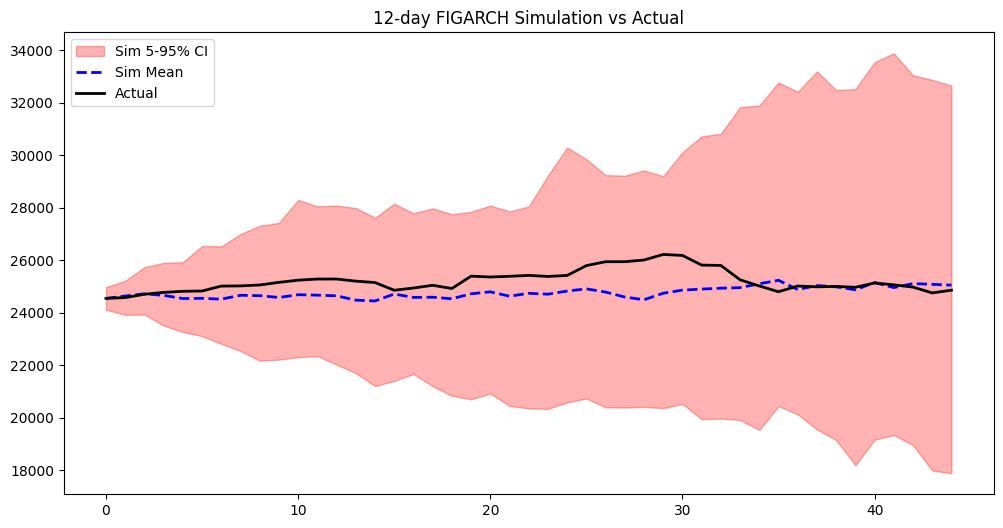

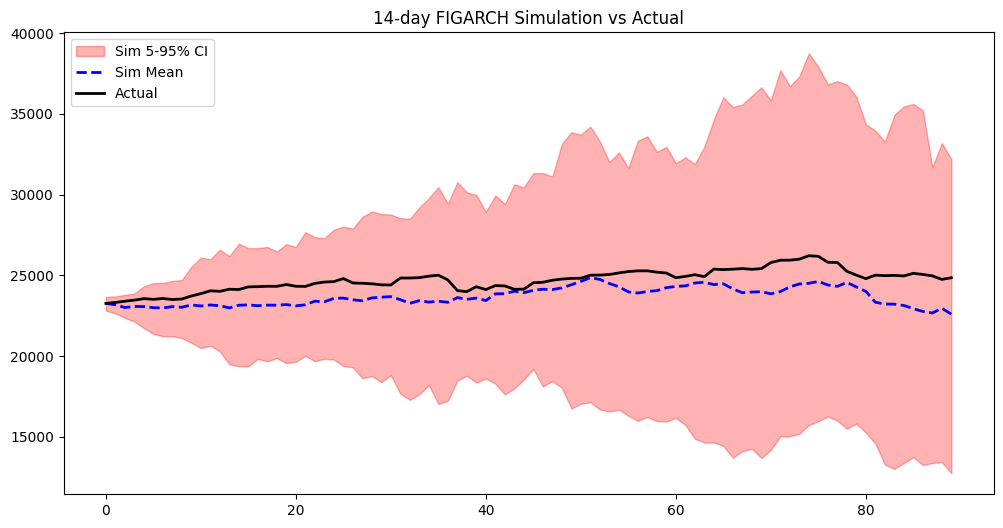

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import t

# -----------------------------
# Utility functions
# -----------------------------
def fit_and_simulate_figarch(returns, last_price, horizon=45, reps=35):
    """
    Fit FIGARCH(1,d,1) model, forecast volatility, and simulate future price paths.
    """
    # Fit FIGARCH(1,d,1) with t-distribution
    fig_mod = arch_model(returns, vol='FIGARCH', p=1, q=1, dist='t')
    fig_fit = fig_mod.fit(disp='off', update_freq=0)

    # Forecast conditional volatility
    forecast = fig_fit.forecast(horizon=horizon, method='analytic')
    sigma_forecast = np.sqrt(forecast.variance.values[-1, :])

    # t-distribution degrees of freedom
    df_t = fig_fit.params['nu']

    # Simulate returns
    sim_returns = np.zeros((horizon, reps))
    for i in range(reps):
        sim_returns[:, i] = sigma_forecast * t.rvs(df=df_t, size=horizon)

    # Convert returns to price paths
    sim_prices = [last_price * np.exp(sim_returns[:, i].cumsum()) for i in range(reps)]

    return pd.DataFrame(sim_prices).T, fig_fit

def compute_sim_metrics(sim_df):
    """
    Compute path-wise and mean-path returns & volatilities.
    """
    # Path-wise returns
    sim_ret = sim_df.apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1, axis=0)
    # Path-wise daily volatility
    sim_vol = sim_df.apply(lambda x: np.std(np.diff(np.log(x))), axis=0)
    # Mean path metrics
    mean_path_ret = (sim_df.mean(1).iloc[-1] / sim_df.mean(1).iloc[0]) - 1
    mean_path_vol = np.std(np.diff(np.log(sim_df.mean(1))))
    return sim_ret, sim_vol, mean_path_ret, mean_path_vol

def plot_sim_vs_actual(sim_df, actual_prices, title):
    """
    Plot simulations vs actual price path with 5-95% confidence intervals.
    Align starting points to the last observed price.
    """
    start_price = actual_prices[0]
    sim_aligned = sim_df + start_price - sim_df.iloc[0].mean()
    n = sim_aligned.shape[0]
    actual_trunc = actual_prices[:n]

    sim_lower = sim_aligned.quantile(0.05, axis=1)
    sim_upper = sim_aligned.quantile(0.95, axis=1)

    plt.figure(figsize=(12,6))
    plt.fill_between(range(n), sim_lower, sim_upper, color='red', alpha=0.3, label='Sim 5-95% CI')
    plt.plot(sim_aligned.mean(axis=1), color='blue', linestyle='--', lw=2, label='Sim Mean')
    plt.plot(actual_trunc, color='black', lw=2, label='Actual')
    plt.title(title)
    plt.legend()
    plt.show()

# -----------------------------
# Example usage for 12- and 14-period horizons
# -----------------------------

# Assume `qRegRet` contains historical log returns
# Assume `oRoi` contains last observed price (DataFrame)
last_price = oRoi.iloc[-1, 0]

# 12-period / 2-month horizon
sim12_df, fit12 = fit_and_simulate_figarch(qRegRet.iloc[:45], last_price, horizon=45, reps=35)
simRet12, simVol12, meanRet12, meanVol12 = compute_sim_metrics(sim12_df)

# 14-period / 3-month horizon
sim14_df, fit14 = fit_and_simulate_figarch(qRegRet.iloc[:90], last_price, horizon=90, reps=35)
simRet14, simVol14, meanRet14, meanVol14 = compute_sim_metrics(sim14_df)

# -----------------------------
# Store results
# -----------------------------
resultDf.loc[rebalDate, ['Ret_Avg','Std_Avg','Avg_Ret','Avg_Std']] = [
    simRet12.mean(), simVol12.mean(), meanRet12, meanVol12
]
resultDf.loc[rebalDate, ['Ret_Avg_3M','Std_Avg_3M','Avg_Ret_3M','Avg_Std_3M']] = [
    simRet14.mean(), simVol14.mean(), meanRet14, meanVol14
]

stDf.loc[rebalDate, '12'] = simVol12.mean()
stDf.loc[rebalDate, '14'] = simVol14.mean()

# -----------------------------
# Compare with actual prices
# -----------------------------
actual12 = closeMergedDf.loc[:rebalDate].iloc[-45:,0].values
actual14 = closeMergedDf.loc[:rebalDate].iloc[-90:,0].values

actual_ret12 = (actual12[-1]/actual12[0])-1
actual_std12 = np.std(np.diff(np.log(actual12)))

actual_ret14 = (actual14[-1]/actual14[0])-1
actual_std14 = np.std(np.diff(np.log(actual14)))

print("12-day actual:", actual_ret12, actual_std12)
print("14-day actual:", actual_ret14, actual_std14)

# -----------------------------
# Plot simulations vs actual
# -----------------------------
plot_sim_vs_actual(sim12_df, actual12, "12-day FIGARCH Simulation vs Actual")
plot_sim_vs_actual(sim14_df, actual14, "14-day FIGARCH Simulation vs Actual")


In [64]:
resultDf

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std,Ret_Avg_3M,Std_Avg_3M,Avg_Ret_3M,Avg_Std_3M
2024-10-18,0.019982,0.031255,0.020298,0.005276,-0.026974,0.040609,-0.027021,0.006795


In [49]:
def simulate_figarch_prices(returns, last_price, horizon=45, rep=35, burn=500):
    """
    Fit FIGARCH(1,d,1) model with t-distribution, then simulate
    forward price paths using the volatility process' simulate method.
    """
    import numpy as np
    from arch import arch_model
    from scipy.stats import t

    # 1️⃣ Fit FIGARCH(1,d,1)
    figarch_mod = arch_model(returns, vol="FIGARCH", p=1, q=1, dist="t")
    figarch_fit = figarch_mod.fit(disp="off")

    # 2️⃣ Extract volatility parameters (in correct order)
    vol_names = figarch_mod.volatility.parameter_names()
    vol_params = np.array([figarch_fit.params[name] for name in vol_names])

    # 3️⃣ Extract degrees of freedom for t-distribution
    df_name = figarch_mod.distribution.parameter_names()[0]  # usually 'nu'
    nu = figarch_fit.params.get(df_name, 8.0)

    # 4️⃣ Simulate from the volatility process
    sim_prices = []
    for i in range(rep):
        # Use np.random.seed for reproducibility
        np.random.seed(i)

        resids, variance = figarch_mod.volatility.simulate(
            parameters=vol_params,
            nobs=horizon,
            burn=burn,
            rng=np.random.standard_normal  # ✅ callable, not Generator object
        )

        sigma = np.sqrt(variance)
        eps = t.rvs(df=nu, size=horizon)
        sim_returns = sigma * eps
        price_path = last_price * np.exp(np.cumsum(sim_returns))
        sim_prices.append(price_path)

    return sim_prices, figarch_fit


In [50]:
simPrice12, figarch_fit12 = simulate_figarch_prices(qRet12, last_price, horizon=45, rep=35)
simPrice14, figarch_fit14 = simulate_figarch_prices(qRet14, last_price, horizon=90, rep=35)

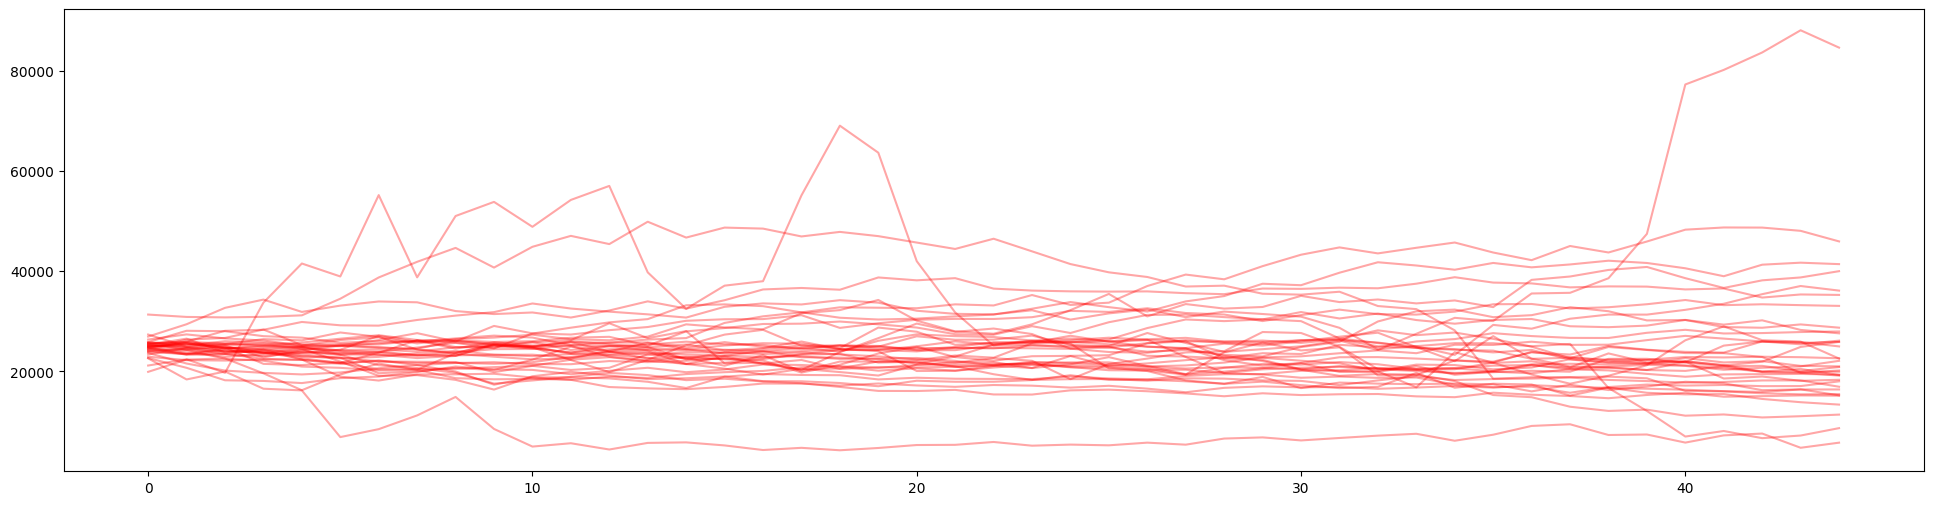

In [51]:
#plot
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice12).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

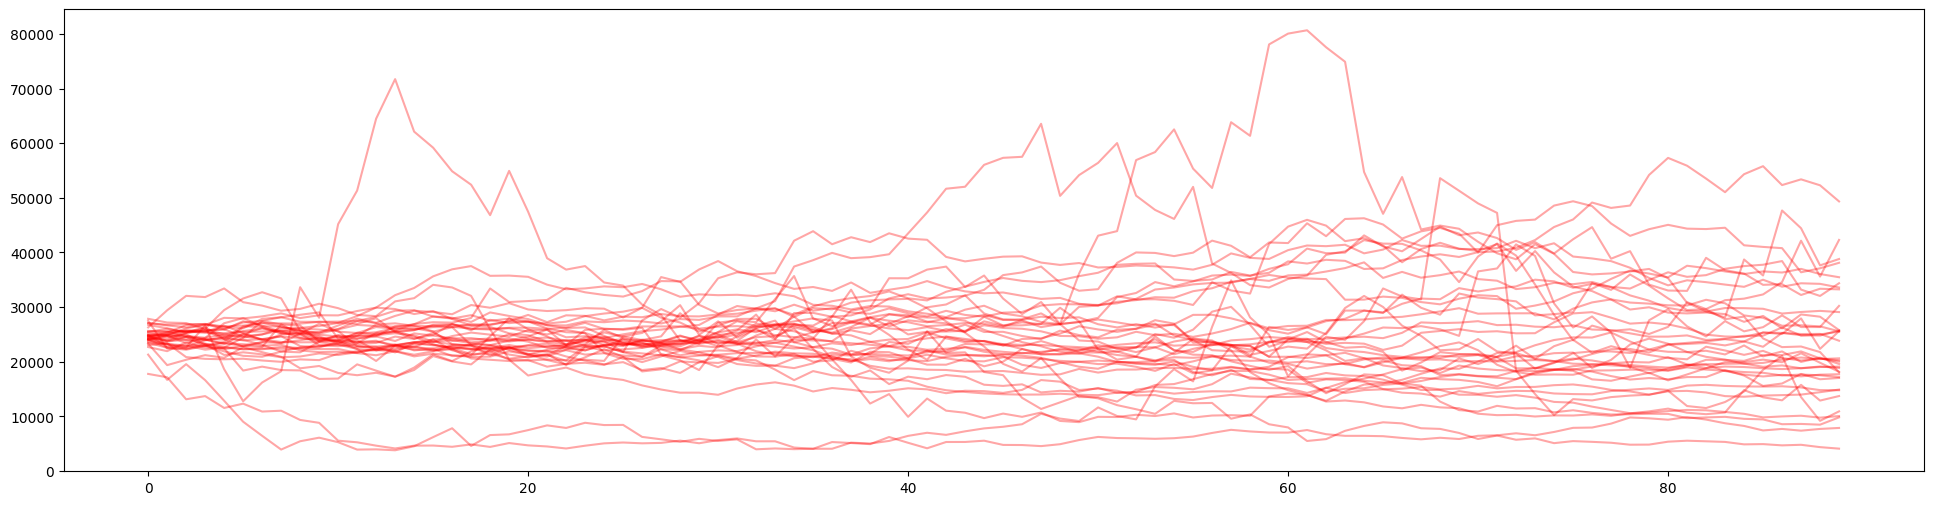

In [52]:
fig, ax = plt.subplots(figsize=(24, 6))
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r', alpha=0.35)
ax.get_legend().remove()

In [53]:
# Calculate metrics
simulDf12 = pd.DataFrame(simPrice12).T
simulDf14 = pd.DataFrame(simPrice14).T

# ----- 2-month (45-day) results -----
# resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
# resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
# resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
# resultDf.loc[rebalDate]['Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
# stDf.loc[rebalDate]['12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))
resultDf.loc[rebalDate, 'Ret_Avg'] = np.mean(simulDf12.apply(lambda x: (x[35] / x[13]) - 1))
resultDf.loc[rebalDate, 'Std_Avg'] = np.mean(simulDf12.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std'] = np.std(np.diff(np.log(simulDf12.mean(1))))
stDf.loc[rebalDate, '12'] = np.mean(np.std(np.diff(np.log(simulDf12), axis=0), axis=0))

# ----- 3-month (90-day) results -----
resultDf.loc[rebalDate, 'Ret_Avg_3M'] = np.mean(simulDf14.apply(lambda x: (x[70] / x[20]) - 1))
resultDf.loc[rebalDate, 'Std_Avg_3M'] = np.mean(simulDf14.apply(lambda x: np.std(np.diff(np.log(x)))))
resultDf.loc[rebalDate, 'Avg_Ret_3M'] = (simulDf14.mean(1)[70] / simulDf14.mean(1)[0]) - 1
resultDf.loc[rebalDate, 'Avg_Std_3M'] = np.std(np.diff(np.log(simulDf14.mean(1))))
stDf.loc[rebalDate, '14'] = np.mean(np.std(np.diff(np.log(simulDf14), axis=0), axis=0))

print(resultDf)
print(stDf)

             Ret_Avg   Std_Avg   Avg_Ret   Avg_Std    Ret_Avg_new  \
2024-10-18 -0.001922  0.061658 -0.029319  0.012099  3.389033e+105   

            Std_Avg_new  Avg_Ret_new  Avg_Std_new  Ret_Avg_3M  Std_Avg_3M  \
2024-10-18     0.353746          inf          NaN    0.214379    0.062798   

            Avg_Ret_3M  Avg_Std_3M  Ret_Avg_3M_new  Std_Avg_3M_new  \
2024-10-18    0.049659    0.013579             inf        2.858031   

            Avg_Ret_3M_new  Avg_Std_3M_new  
2024-10-18            -1.0             NaN  
                  12        14  12_new  14_new
2024-10-18  0.061658  0.062798     NaN     NaN


In [54]:
resultDf

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std,Ret_Avg_new,Std_Avg_new,Avg_Ret_new,Avg_Std_new,Ret_Avg_3M,Std_Avg_3M,Avg_Ret_3M,Avg_Std_3M,Ret_Avg_3M_new,Std_Avg_3M_new,Avg_Ret_3M_new,Avg_Std_3M_new
2024-10-18,-0.001922,0.061658,-0.029319,0.012099,3.389033e+105,0.353746,inf,NaN,0.214379,0.062798,0.049659,0.013579,inf,2.858031,-1.0,NaN


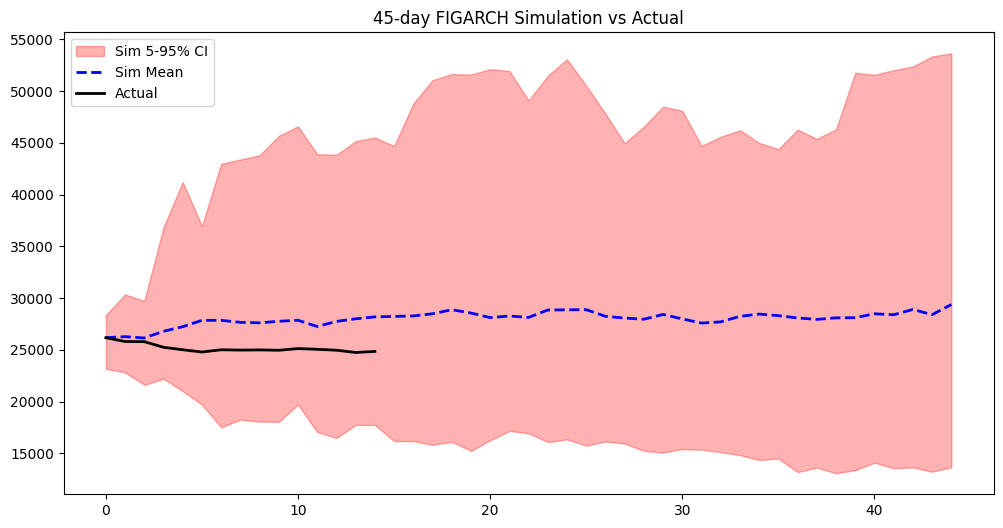

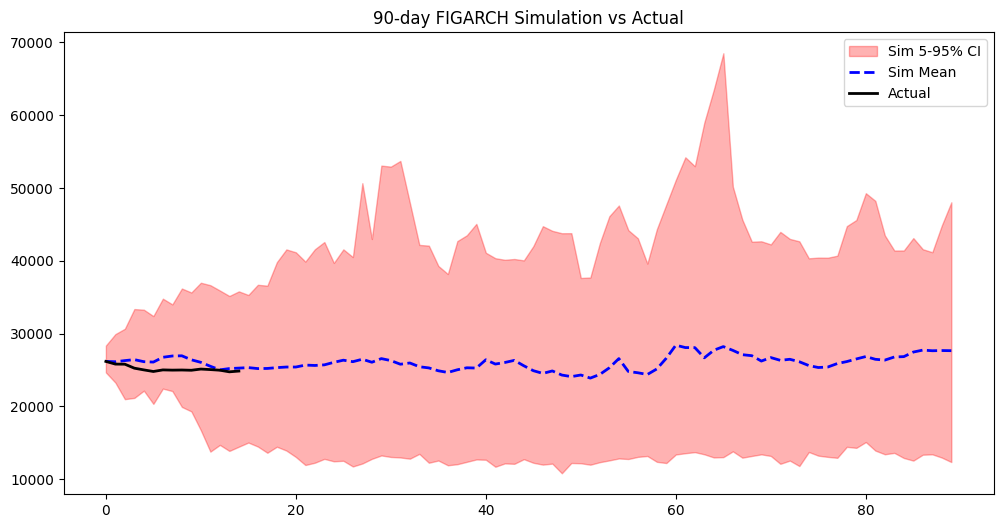

             Ret_Avg   Std_Avg   Avg_Ret   Avg_Std  Ret_Avg_3M  Std_Avg_3M  \
2024-10-18  0.136412  0.066276  0.130453  0.013598     0.05988    0.067247   

            Avg_Ret_3M  Avg_Std_3M  
2024-10-18    0.059864    0.021873  
                  45        90
2024-10-18  0.066276  0.067247


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import t

# -----------------------------
# 1️⃣ FIGARCH simulation function
# -----------------------------
def simulate_figarch_prices(returns, last_price, horizon=45, rep=35, burn=500):
    """
    Fit FIGARCH(1,d,1) with t-distribution, simulate forward price paths.
    Returns a DataFrame of simulated price paths and the fitted model.
    """
    figarch_mod = arch_model(returns, vol="FIGARCH", p=1, q=1, dist="t")
    figarch_fit = figarch_mod.fit(disp="off")

    # Extract parameters
    vol_params = np.array([figarch_fit.params[name] for name in figarch_mod.volatility.parameter_names()])
    nu = figarch_fit.params.get(figarch_mod.distribution.parameter_names()[0], 8.0)

    sim_prices = []
    for i in range(rep):
        rng = np.random.default_rng(i)
        resids, variance = figarch_mod.volatility.simulate(
            parameters=vol_params,
            nobs=horizon,
            burn=burn,
            rng=rng.standard_normal
        )

        sigma = np.sqrt(variance)
        eps = t.rvs(df=nu, size=horizon, random_state=rng)
        sim_returns = sigma * eps
        price_path = last_price * np.exp(np.cumsum(sim_returns))
        sim_prices.append(price_path)

    return pd.DataFrame(sim_prices).T, figarch_fit

# -----------------------------
# 2️⃣ Metrics computation
# -----------------------------
def compute_sim_metrics(sim_df):
    """
    Compute path-wise and mean-path returns & volatilities.
    """
    sim_ret = sim_df.apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1, axis=0)
    sim_vol = sim_df.apply(lambda x: np.std(np.diff(np.log(x))), axis=0)
    mean_path_ret = (sim_df.mean(1).iloc[-1] / sim_df.mean(1).iloc[0]) - 1
    mean_path_vol = np.std(np.diff(np.log(sim_df.mean(1))))
    return sim_ret, sim_vol, mean_path_ret, mean_path_vol

# -----------------------------
# 3️⃣ Plotting aligned simulations
# -----------------------------
def plot_sim_vs_actual(sim_df, actual_prices, title):
    """
    Plot simulations vs actual price path with 5-95% confidence intervals.
    Align starting points to last observed price.
    """
    start_price = actual_prices[0]
    sim_aligned = sim_df + start_price - sim_df.iloc[0].mean()
    n = sim_aligned.shape[0]
    actual_trunc = actual_prices[:n]

    sim_lower = sim_aligned.quantile(0.05, axis=1)
    sim_upper = sim_aligned.quantile(0.95, axis=1)

    plt.figure(figsize=(12,6))
    plt.fill_between(range(n), sim_lower, sim_upper, color='red', alpha=0.3, label='Sim 5-95% CI')
    plt.plot(sim_aligned.mean(axis=1), color='blue', linestyle='--', lw=2, label='Sim Mean')
    plt.plot(actual_trunc, color='black', lw=2, label='Actual')
    plt.title(title)
    plt.legend()
    plt.show()

# -----------------------------
# 4️⃣ Main pipeline function
# -----------------------------
def run_figarch_simulation(qRegRet, oRoi, rebalDate, horizons=[45, 90], reps=35):
    """
    Run FIGARCH simulation pipeline for multiple horizons and store results.
    Returns result DataFrame and path-wise vol DataFrame.
    """
    resultDf = pd.DataFrame(index=[rebalDate])
    stDf = pd.DataFrame(index=[rebalDate])

    last_price = oRoi.iloc[-1, 0]

    for h in horizons:
        sim_df, fit = simulate_figarch_prices(qRegRet.iloc[:h], last_price, horizon=h, rep=reps)
        sim_ret, sim_vol, mean_ret, mean_vol = compute_sim_metrics(sim_df)

        # Store results
        if h == 45:
            prefix = ""
        else:
            prefix = "_3M"
        resultDf.loc[rebalDate, f"Ret_Avg{prefix}"] = sim_ret.mean()
        resultDf.loc[rebalDate, f"Std_Avg{prefix}"] = sim_vol.mean()
        resultDf.loc[rebalDate, f"Avg_Ret{prefix}"] = mean_ret
        resultDf.loc[rebalDate, f"Avg_Std{prefix}"] = mean_vol
        stDf.loc[rebalDate, str(h)] = sim_vol.mean()

        # Plot
        actual_prices = oRoi.iloc[-h:, 0].values
        plot_sim_vs_actual(sim_df, actual_prices, f"{h}-day FIGARCH Simulation vs Actual")

    return resultDf, stDf

# -----------------------------
# 5️⃣ Example usage
# -----------------------------
# qRegRet = your historical log returns for the query regime
# oRoi = last observed price DataFrame
# rebalDate = '2024-10-18'

resultDf, stDf = run_figarch_simulation(qRegRet, oRoi, rebalDate, horizons=[45, 90], reps=35)

print(resultDf)
print(stDf)


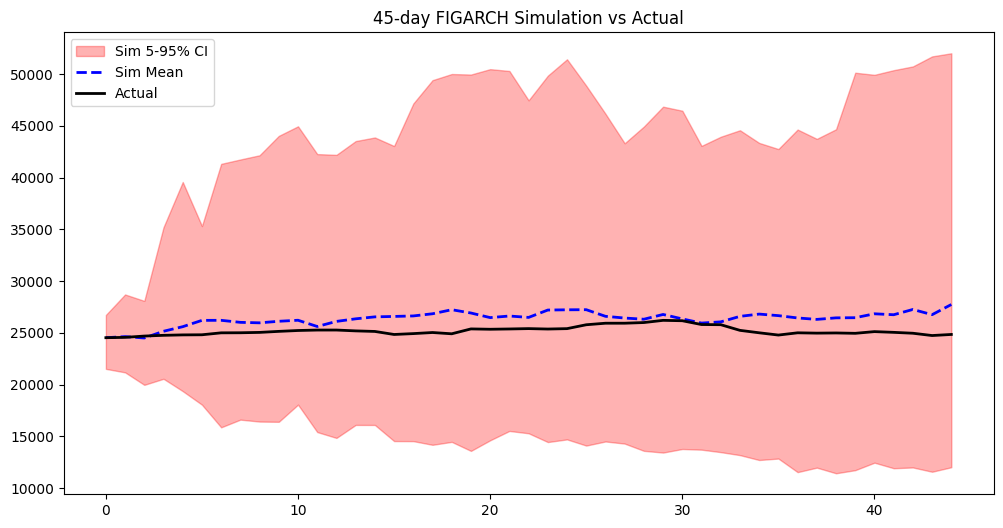

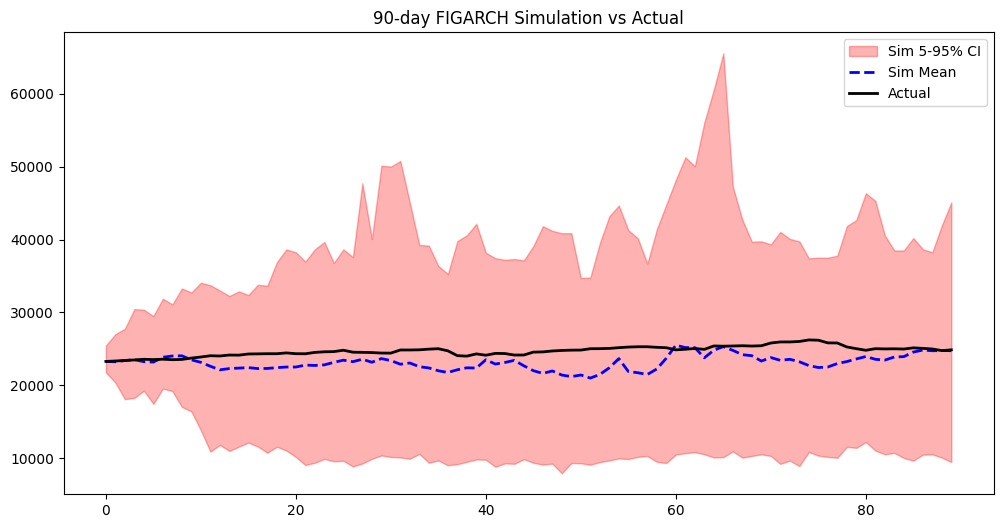

             Ret_Avg   Std_Avg   Avg_Ret   Avg_Std  Ret_Avg_3M  Std_Avg_3M  \
2024-10-18  0.136412  0.066276  0.130453  0.013598     0.05988    0.067247   

            Avg_Ret_3M  Avg_Std_3M  
2024-10-18    0.059864    0.021873  
                  45        90
2024-10-18  0.066276  0.067247


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import t

# -----------------------------
# 1️⃣ FIGARCH simulation function
# -----------------------------
def simulate_figarch_prices(returns, last_price, horizon=45, rep=35, burn=500):
    """
    Fit FIGARCH(1,d,1) with t-distribution, simulate forward price paths.
    Returns a DataFrame of simulated price paths and the fitted model.
    """
    figarch_mod = arch_model(returns, vol="FIGARCH", p=1, q=1, dist="t")
    figarch_fit = figarch_mod.fit(disp="off")

    # Extract parameters
    vol_params = np.array([figarch_fit.params[name] for name in figarch_mod.volatility.parameter_names()])
    nu = figarch_fit.params.get(figarch_mod.distribution.parameter_names()[0], 8.0)

    sim_prices = []
    for i in range(rep):
        rng = np.random.default_rng(i)
        resids, variance = figarch_mod.volatility.simulate(
            parameters=vol_params,
            nobs=horizon,
            burn=burn,
            rng=rng.standard_normal
        )

        sigma = np.sqrt(variance)
        eps = t.rvs(df=nu, size=horizon, random_state=rng)
        sim_returns = sigma * eps
        price_path = last_price * np.exp(np.cumsum(sim_returns))
        sim_prices.append(price_path)

    return pd.DataFrame(sim_prices).T, figarch_fit

# -----------------------------
# 2️⃣ Metrics computation
# -----------------------------
def compute_sim_metrics(sim_df):
    sim_ret = sim_df.apply(lambda x: (x.iloc[-1] / x.iloc[0]) - 1, axis=0)
    sim_vol = sim_df.apply(lambda x: np.std(np.diff(np.log(x))), axis=0)
    mean_path_ret = (sim_df.mean(1).iloc[-1] / sim_df.mean(1).iloc[0]) - 1
    mean_path_vol = np.std(np.diff(np.log(sim_df.mean(1))))
    return sim_ret, sim_vol, mean_path_ret, mean_path_vol

# -----------------------------
# 3️⃣ Plotting aligned simulations
# -----------------------------
def plot_sim_vs_actual(sim_df, actual_prices, title):
    """
    Plot simulations vs actual price path with 5-95% confidence intervals.
    Align starting points to last observed price.
    Automatically truncates or pads actual_prices to match simulation horizon.
    """
    start_price = actual_prices[0]
    sim_aligned = sim_df + start_price - sim_df.iloc[0].mean()
    n = sim_aligned.shape[0]

    # Ensure actual_prices length matches simulation horizon
    if len(actual_prices) < n:
        # pad with last observed price
        actual_prices = np.concatenate([actual_prices, np.repeat(actual_prices[-1], n - len(actual_prices))])
    else:
        actual_prices = actual_prices[-n:]

    sim_lower = sim_aligned.quantile(0.05, axis=1)
    sim_upper = sim_aligned.quantile(0.95, axis=1)

    plt.figure(figsize=(12,6))
    plt.fill_between(range(n), sim_lower, sim_upper, color='red', alpha=0.3, label='Sim 5-95% CI')
    plt.plot(sim_aligned.mean(axis=1), color='blue', linestyle='--', lw=2, label='Sim Mean')
    plt.plot(actual_prices, color='black', lw=2, label='Actual')
    plt.title(title)
    plt.legend()
    plt.show()

# -----------------------------
# 4️⃣ Main pipeline function
# -----------------------------
def run_figarch_simulation(qRegRet, closeMergedDf, rebalDate, horizons=[45, 90], reps=35):
    """
    Run FIGARCH simulation pipeline for multiple horizons and store results.
    Handles automatic alignment of actual prices for plotting.
    Returns result DataFrame and path-wise vol DataFrame.
    """
    resultDf = pd.DataFrame(index=[rebalDate])
    stDf = pd.DataFrame(index=[rebalDate])

    last_price = closeMergedDf.loc[:rebalDate].iloc[-1, 0]

    for h in horizons:
        sim_df, fit = simulate_figarch_prices(qRegRet.iloc[:h], last_price, horizon=h, rep=reps)
        sim_ret, sim_vol, mean_ret, mean_vol = compute_sim_metrics(sim_df)

        # Store results
        prefix = "" if h==45 else "_3M"
        resultDf.loc[rebalDate, f"Ret_Avg{prefix}"] = sim_ret.mean()
        resultDf.loc[rebalDate, f"Std_Avg{prefix}"] = sim_vol.mean()
        resultDf.loc[rebalDate, f"Avg_Ret{prefix}"] = mean_ret
        resultDf.loc[rebalDate, f"Avg_Std{prefix}"] = mean_vol
        stDf.loc[rebalDate, str(h)] = sim_vol.mean()

        # Get actual prices for the horizon
        actual_prices = closeMergedDf.loc[:rebalDate].iloc[-h:, 0].values
        plot_sim_vs_actual(sim_df, actual_prices, f"{h}-day FIGARCH Simulation vs Actual")

    return resultDf, stDf

# -----------------------------
# 5️⃣ Example usage
# -----------------------------
# qRegRet = historical log returns for the query regime
# closeMergedDf = merged price DataFrame
# rebalDate = '2024-10-18'

resultDf, stDf = run_figarch_simulation(qRegRet, closeMergedDf, rebalDate, horizons=[45, 90], reps=35)

print(resultDf)
print(stDf)
